# EDA — Performance 1010 vs 1020 (mapping UI đã chứng minh)

Notebook nối tiếp logic **`eda_category_mapping_proof.ipynb`**:

| `category` | UI (đúng) | Ghi chú README (sai — chỉ đối chiếu) |
|------------|-----------|--------------------------------------|
| **1010** | Căn hộ / Chung cư | Phòng trọ / căn hộ cho thuê |
| **1020** | Nhà ở | Căn hộ / chung cư |

**Mục tiêu:** đo **CVR** (tin có ≥1 sự kiện tích cực trên `fact_user_events`) và **đối chiếu với đặc trưng dữ liệu** để thấy performance thay đổi theo cohort — **không** so cohort chéo bằng field chỉ meaningful một bên (vd. `house_type`/`floors` chỉ 1020; `project_id` nặng 1010).

**CVR (định nghĩa giống §9 notebook mapping):** `LEFT JOIN` listing với tập `item_id` có `event_type` ∈ {view_phone, contact_chat, other_interaction, contact_zalo, contact_sms}.

**Phạm vi tin (quan trọng):** `dim_listing` có `posted_date` từ **2024-09** nhưng `fact_user_events` / `fact_listing_snapshot` chỉ từ **2025-11-09**. CVR và profile dùng **toàn bộ catalog** `dim_listing` (1010+1020); §0 đối chiếu `posted_date` vs cửa sổ facts và overlap snapshot/events.

**Chạy:** mở từ thư mục gốc `Datathon_Data` (có `dim_listing/`, `fact_user_events/`, `fact_listing_snapshot/`). Kernel: `requirements-eda.txt`. **Run All** từ cell setup. Kernel: `requirements-eda.txt`. **Run All** từ cell setup — không chạy lẻ cell CVR sau khi restart kernel.

**Quy tắc field:** `outputs/category_mapping/13_dim_listing_eda_role_matrix.csv` (đúc kết từ `eda_category_mapping_proof.ipynb`).

**Export:** `outputs/eda_category_1010_1020/`

In [ ]:
%matplotlib inline

from __future__ import annotations

import warnings
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")

DATA_ROOT = Path.cwd().resolve()
for name in ("dim_listing", "fact_user_events", "fact_listing_snapshot"):
    if not (DATA_ROOT / name).exists():
        raise FileNotFoundError(f"Thiếu `{name}` trong {DATA_ROOT}")

OUT_DIR = DATA_ROOT / "outputs" / "eda_category_1010_1020"
OUT_DIR.mkdir(parents=True, exist_ok=True)

DIM_GLOB = str(DATA_ROOT / "dim_listing" / "*.parquet")
EVENTS_GLOB = str(DATA_ROOT / "fact_user_events" / "*.parquet")
SNAP_GLOB = str(DATA_ROOT / "fact_listing_snapshot" / "*.parquet")

DUCKDB_MEMORY_LIMIT = "2GB"
DUCKDB_THREADS = 2
# None = full events scan; 0.08 nếu thiếu RAM (CVR tương đối). KHÔNG đặt 0.
EVENT_SAMPLE_FRAC: float | None = None

POSITIVE_TYPES = (
    "view_phone",
    "contact_chat",
    "other_interaction",
    "contact_zalo",
    "contact_sms",
)
POS_SQL = ", ".join(repr(x) for x in POSITIVE_TYPES)
CAT_SQL = "1010, 1020"

README_LABELS = {
    1010: "README: Phòng trọ / CH thuê",
    1020: "README: Căn hộ / CH",
}
UI_LABELS = {1010: "1010 Căn hộ / Chung cư", 1020: "1020 Nhà ở"}
CATS = (1010, 1020)
AREA_BUCKET_ORDER = ("<30", "30-50", "50-80", "80-120", "120+", "unknown_or_0")

RULES_CSV = DATA_ROOT / "outputs" / "category_mapping" / "13_dim_listing_eda_rules_long.csv"
EDA_RULES = pd.read_csv(RULES_CSV)
EDA_RULES = EDA_RULES[EDA_RULES["category"].isin(CATS)]

con = duckdb.connect(":memory:")
con.execute(f"PRAGMA memory_limit='{DUCKDB_MEMORY_LIMIT}'")
con.execute(f"PRAGMA threads={DUCKDB_THREADS}")


def sample_clause(frac: float | None) -> str:
    if frac is None:
        return ""
    if not (0 < float(frac) < 1):
        raise ValueError(f"EVENT_SAMPLE_FRAC phải None hoặc trong (0,1), got {frac}")
    return f"AND random() < {float(frac)}"


def show_cvr_table(df: pd.DataFrame, title: str):
    display(Markdown(f"**{title}**"))
    display(df)


def cvr_by_dims(select_dims: str, where: str = "TRUE", min_n: int = 500) -> pd.DataFrame:
    """CVR từ TEMP TABLE listing_feats × pos_items (một lần scan events)."""
    sql = f"""
    SELECT
        {select_dims},
        COUNT(*)::BIGINT AS listings,
        SUM(CASE WHEN p.item_id IS NOT NULL THEN 1 ELSE 0 END)::BIGINT AS listings_with_positive,
        ROUND(
            100.0 * SUM(CASE WHEN p.item_id IS NOT NULL THEN 1 ELSE 0 END) / NULLIF(COUNT(*), 0),
            2
        ) AS cvr_pct
    FROM listing_feats l
    LEFT JOIN pos_items p ON l.item_id = p.item_id
    WHERE {where}
    GROUP BY ALL
    HAVING COUNT(*) >= {int(min_n)}
    """
    return con.execute(sql).df()


def attach_labels(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    if "category" in out.columns:
        out["ui_label"] = out["category"].map(UI_LABELS)
        out["readme_label"] = out["category"].map(README_LABELS)
    return out


def assert_cvr_sane(df: pd.DataFrame, label: str, min_pos: int = 1):
    pos = int(df["listings_with_positive"].sum()) if len(df) else 0
    if pos < min_pos:
        raise RuntimeError(
            f"{label}: listings_with_positive={pos}. Chạy lại **Run All** từ cell setup; "
            "kiểm tra EVENT_SAMPLE_FRAC, fact_user_events và listing_feats."
        )


print("OUT_DIR =", OUT_DIR)
print("EVENT_SAMPLE_FRAC =", EVENT_SAMPLE_FRAC)
print("EDA rules rows (1010+1020):", len(EDA_RULES))

eda_dates = con.execute(f"""
SELECT
    (SELECT MIN(date) FROM read_parquet('{EVENTS_GLOB}')) AS events_min_date,
    (SELECT MAX(date) FROM read_parquet('{EVENTS_GLOB}')) AS events_max_date,
    (SELECT MIN(date) FROM read_parquet('{SNAP_GLOB}')) AS snapshot_min_date,
    (SELECT MAX(date) FROM read_parquet('{SNAP_GLOB}')) AS snapshot_max_date
""").df().iloc[0]
EDA_MIN_DATE = eda_dates["snapshot_min_date"]
EDA_MAX_DATE = eda_dates["snapshot_max_date"]
print(f"EDA window (snapshot): {EDA_MIN_DATE} → {EDA_MAX_DATE}")

print("Building pos_items …")
con.execute(f"""
CREATE OR REPLACE TEMP TABLE pos_items AS
SELECT DISTINCT CAST(item_id AS VARCHAR) AS item_id
FROM read_parquet('{EVENTS_GLOB}')
WHERE event_type IN ({POS_SQL})
  {sample_clause(EVENT_SAMPLE_FRAC)}
""")
n_pos = con.execute("SELECT COUNT(*) FROM pos_items").fetchone()[0]
if n_pos == 0:
    raise RuntimeError("pos_items rỗng — kiểm tra EVENT_SAMPLE_FRAC và fact_user_events")
print(f"pos_items = {n_pos:,} listings có ≥1 positive event")

print("Building dim_scoped (catalog 1010+1020) + overlap flags …")
con.execute(f"""
CREATE OR REPLACE TEMP TABLE listings_in_events AS
SELECT DISTINCT CAST(item_id AS VARCHAR) AS item_id
FROM read_parquet('{EVENTS_GLOB}')
WHERE category IN ({CAT_SQL})
""")
con.execute(f"""
CREATE OR REPLACE TEMP TABLE listings_in_snapshot AS
SELECT DISTINCT CAST(s.item_id AS VARCHAR) AS item_id
FROM read_parquet('{SNAP_GLOB}') s
INNER JOIN read_parquet('{DIM_GLOB}') d
    ON CAST(s.item_id AS VARCHAR) = CAST(d.item_id AS VARCHAR)
WHERE d.category IN ({CAT_SQL})
""")
con.execute(f"""
CREATE OR REPLACE TEMP TABLE dim_scoped AS
SELECT
    d.*,
    CASE
        WHEN d.posted_date IS NULL THEN 'unknown_posted'
        WHEN d.posted_date < DATE '{EDA_MIN_DATE}' THEN 'pre_eda_window'
        WHEN d.posted_date > DATE '{EDA_MAX_DATE}' THEN 'post_eda_window'
        ELSE 'in_eda_window'
    END AS posted_cohort
FROM read_parquet('{DIM_GLOB}') d
WHERE d.category IN ({CAT_SQL})
""")
n_scope = con.execute("SELECT COUNT(*) FROM dim_scoped").fetchone()[0]
if n_scope == 0:
    raise RuntimeError("dim_scoped rỗng — kiểm tra dim_listing")

print("Building listing_feats …")
con.execute("""
CREATE OR REPLACE TEMP TABLE listing_feats AS
SELECT
    CAST(item_id AS VARCHAR) AS item_id,
    category,
    ad_type,
    posted_cohort,
    area_sqm,
    bedrooms,
    CASE WHEN project_id IS NOT NULL AND TRIM(CAST(project_id AS VARCHAR)) != ''
         THEN 1 ELSE 0 END AS has_project,
    CASE WHEN furnishing IS NOT NULL AND TRIM(CAST(furnishing AS VARCHAR)) != ''
         THEN 1 ELSE 0 END AS has_furnishing,
    CASE
        WHEN bedrooms IS NULL OR bedrooms <= 0 THEN 'unknown_or_0'
        WHEN bedrooms = 1 THEN '1'
        WHEN bedrooms = 2 THEN '2'
        WHEN bedrooms = 3 THEN '3'
        ELSE '4+'
    END AS bed_bucket,
    COALESCE(NULLIF(TRIM(CAST(house_type AS VARCHAR)), ''), '(blank)') AS house_type,
    CASE
        WHEN floors IS NULL OR floors <= 0 THEN 'unknown_or_0'
        WHEN floors <= 2 THEN '1-2'
        WHEN floors <= 4 THEN '3-4'
        ELSE '5+'
    END AS floors_bucket,
    CASE WHEN width_m IS NOT NULL AND width_m > 0 THEN 1 ELSE 0 END AS has_width_m,
    CASE WHEN legal_status IS NOT NULL AND TRIM(CAST(legal_status AS VARCHAR)) != ''
         THEN 1 ELSE 0 END AS has_legal,
    CASE
        WHEN area_sqm IS NULL OR area_sqm <= 0 THEN 'unknown_or_0'
        WHEN area_sqm < 30 THEN '<30'
        WHEN area_sqm < 50 THEN '30-50'
        WHEN area_sqm < 80 THEN '50-80'
        WHEN area_sqm < 120 THEN '80-120'
        ELSE '120+'
    END AS area_bucket
FROM dim_scoped
""")
n_list = con.execute("SELECT COUNT(*) FROM listing_feats").fetchone()[0]
n_dim_all = con.execute(f"""
    SELECT COUNT(*) FROM read_parquet('{DIM_GLOB}') WHERE category IN ({CAT_SQL})
""").fetchone()[0]
n_in_events = con.execute("""
    SELECT COUNT(*) FROM dim_scoped d
    INNER JOIN listings_in_events e ON CAST(d.item_id AS VARCHAR) = e.item_id
""").fetchone()[0]
n_in_snap = con.execute("""
    SELECT COUNT(*) FROM dim_scoped d
    INNER JOIN listings_in_snapshot s ON CAST(d.item_id AS VARCHAR) = s.item_id
""").fetchone()[0]
n_pos_catalog = con.execute("""
    SELECT COUNT(*) FROM listing_feats l
    INNER JOIN pos_items p ON l.item_id = p.item_id
""").fetchone()[0]
print(f"dim_listing 1010+1020 (catalog / CVR mẫu): {n_dim_all:,}")
print(f"  có event trong cửa sổ facts: {n_in_events:,}")
print(f"  có snapshot daily: {n_in_snap:,}")
print(f"listing_feats = {n_list:,} rows")
print(
    f"CVR catalog ≈ {100 * n_pos_catalog / max(n_list, 1):.1f}% "
    f"({n_pos_catalog:,} tin có ≥1 positive / {n_list:,})"
)


## 0 — Time coverage & phạm vi `dim_listing`

`dim_listing` là dimension **tĩnh** (`posted_date` từ 2024-09); facts (`fact_user_events`, `fact_listing_snapshot`) từ **2025-11-09**. Chart CVR §2–§5 dùng **catalog đầy đủ** (giống notebook mapping); bảng dưới giải thích overlap và `posted_cohort`.

In [ ]:
time_cov = con.execute(f"""
SELECT * FROM (
    SELECT
        'dim_listing.posted_date (1010+1020)' AS table,
        CAST(MIN(posted_date) AS DATE) AS min_time,
        CAST(MAX(posted_date) AS DATE) AS max_time,
        COUNT(*)::BIGINT AS n_rows
    FROM dim_scoped
    UNION ALL
    SELECT
        'fact_listing_snapshot.date' AS table,
        CAST(MIN(date) AS DATE),
        CAST(MAX(date) AS DATE),
        COUNT(*)::BIGINT
    FROM read_parquet('{SNAP_GLOB}')
    UNION ALL
    SELECT
        'fact_user_events.date' AS table,
        CAST(MIN(date) AS DATE),
        CAST(MAX(date) AS DATE),
        COUNT(*)::BIGINT
    FROM read_parquet('{EVENTS_GLOB}')
) ORDER BY table
""").df()
display(Markdown("**Bảng 0 — Time coverage (dim vs facts)**"))
display(time_cov)
time_cov.to_csv(OUT_DIR / "00_time_coverage.csv", index=False)

cohort_cvr = con.execute(f"""
SELECT
    l.posted_cohort,
    COUNT(*)::BIGINT AS listings,
    SUM(CASE WHEN p.item_id IS NOT NULL THEN 1 ELSE 0 END)::BIGINT AS with_positive,
    ROUND(
        100.0 * SUM(CASE WHEN p.item_id IS NOT NULL THEN 1 ELSE 0 END) / NULLIF(COUNT(*), 0),
        2
    ) AS cvr_pct
FROM listing_feats l
LEFT JOIN pos_items p ON l.item_id = p.item_id
GROUP BY 1
ORDER BY 1
""").df()
display(Markdown(
    "**CVR theo `posted_cohort`** — giải thích vì sao `dim_listing` rộng hơn facts: "
    "tin `pre_eda_window` (~85% catalog) hầu như không có contact trong cửa sổ events."
))
display(cohort_cvr)
cohort_cvr.to_csv(OUT_DIR / "00_posted_cohort_cvr.csv", index=False)

scope_summary = con.execute("""
SELECT
    category,
    COUNT(*) AS listings_in_catalog,
    SUM(CASE WHEN p.item_id IS NOT NULL THEN 1 ELSE 0 END) AS with_positive_event
FROM listing_feats l
LEFT JOIN pos_items p ON l.item_id = p.item_id
GROUP BY 1 ORDER BY 1
""").df()
scope_summary["ui_label"] = scope_summary["category"].map(UI_LABELS)
scope_summary["cvr_pct"] = (
    100.0 * scope_summary["with_positive_event"] / scope_summary["listings_in_catalog"]
).round(2)
display(Markdown("**CVR catalog theo category (mẫu chính cho §2–§5)**"))
display(scope_summary)
scope_summary.to_csv(OUT_DIR / "00_scope_summary.csv", index=False)


## 1 — Hồ sơ đặc trưng (đối chiếu chứng minh mapping)

Tóm tắt **độ đầy field** và mix `ad_type` để giải thích vì sao một số lát cắt performance chỉ áp dụng cho một phân khúc.

In [ ]:
profile = con.execute(f"""
SELECT
    category,
    COUNT(*) AS n,
    ROUND(100.0 * SUM(CASE WHEN ad_type = 'let' THEN 1 ELSE 0 END) / COUNT(*), 2) AS pct_let,
    ROUND(100.0 * SUM(CASE
        WHEN CAST(price_bucket AS VARCHAR) LIKE '%/tháng%'
          OR CAST(price_bucket AS VARCHAR) LIKE '%M/tháng%'
          OR CAST(price_bucket AS VARCHAR) LIKE '%triệu/tháng%'
        THEN 1 ELSE 0 END) / COUNT(*), 2) AS pct_monthly_price_bucket,
    ROUND(100.0 * SUM(CASE WHEN bedrooms IS NOT NULL AND bedrooms > 0 THEN 1 ELSE 0 END) / COUNT(*), 2) AS pct_bedrooms_gt0,
    ROUND(100.0 * SUM(CASE WHEN bathrooms IS NOT NULL AND bathrooms > 0 THEN 1 ELSE 0 END) / COUNT(*), 2) AS pct_bathrooms_gt0,
    ROUND(100.0 * SUM(CASE WHEN project_id IS NOT NULL AND TRIM(project_id::VARCHAR) != '' THEN 1 ELSE 0 END) / COUNT(*), 2) AS pct_has_project_id,
    ROUND(100.0 * SUM(CASE WHEN furnishing IS NOT NULL AND TRIM(furnishing::VARCHAR) != '' THEN 1 ELSE 0 END) / COUNT(*), 2) AS pct_furnishing_filled,
    ROUND(100.0 * SUM(CASE WHEN floors IS NOT NULL AND floors > 0 THEN 1 ELSE 0 END) / COUNT(*), 2) AS pct_floors_gt0,
    ROUND(100.0 * SUM(CASE WHEN width_m IS NOT NULL AND width_m > 0 THEN 1 ELSE 0 END) / COUNT(*), 2) AS pct_width_m_gt0,
    ROUND(100.0 * SUM(CASE WHEN house_type IS NOT NULL AND TRIM(house_type::VARCHAR) != '' THEN 1 ELSE 0 END) / COUNT(*), 2) AS pct_house_type_nonempty,
    ROUND(100.0 * SUM(CASE WHEN legal_status IS NOT NULL AND TRIM(legal_status::VARCHAR) != '' THEN 1 ELSE 0 END) / COUNT(*), 2) AS pct_legal_filled
FROM dim_scoped
GROUP BY 1 ORDER BY 1
""").df()
profile["ui_label"] = profile["category"].map(UI_LABELS)
profile["readme_label"] = profile["category"].map(README_LABELS)
show_cvr_table(profile, "Bảng 1 — Hồ sơ đặc trưng 1010 vs 1020")
profile.to_csv(OUT_DIR / "01_profile_1010_1020.csv", index=False)

## 2 — CVR tổng theo `category` × `ad_type`

Baseline performance; stratify tiếp theo các đặc trưng meaningful trong mỗi nhóm.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

**Bảng 2 — CVR baseline**

,category,ad_type,listings,listings_with_positive,cvr_pct,ui_label,readme_label
0,1010,let,454716,85640,18.83,1010 Căn hộ / Chung cư,README: Phòng trọ / CH thuê
1,1010,sell,157107,36134,23.00,1010 Căn hộ / Chung cư,README: Phòng trọ / CH thuê
2,1020,let,426019,87112,20.45,1020 Nhà ở,README: Căn hộ / CH
3,1020,sell,1081845,209026,19.32,1020 Nhà ở,README: Căn hộ / CH


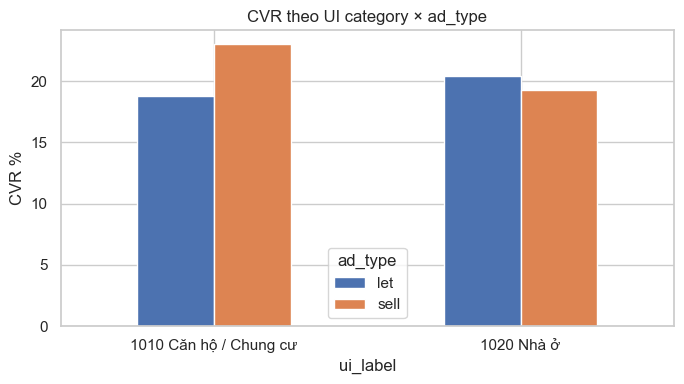

In [3]:
base_cvr = attach_labels(cvr_by_dims("l.category, l.ad_type", min_n=1))
base_cvr = base_cvr.sort_values(["category", "ad_type"]).reset_index(drop=True)
assert_cvr_sane(base_cvr, "baseline")
show_cvr_table(base_cvr, "Bảng 2 — CVR baseline")
base_cvr.to_csv(OUT_DIR / "02_cvr_baseline_adtype.csv", index=False)

fig, ax = plt.subplots(figsize=(7, 4))
plot_df = base_cvr.pivot(index="ui_label", columns="ad_type", values="cvr_pct")
plot_df.plot(kind="bar", ax=ax, rot=0)
ax.set_ylabel("CVR %")
ax.set_title("CVR theo UI category × ad_type")
ax.legend(title="ad_type")
plt.tight_layout()
fig.savefig(OUT_DIR / "fig_cvr_baseline_adtype.png", dpi=120, bbox_inches="tight")
plt.show()

## 3 — Đặc trưng **chỉ meaningful 1010** → CVR theo lát cắt

- `has_project`, `bedrooms` bucket, `furnishing` có/không  
- Không dùng `house_type` / `floors` / `width_m` cho cohort chuẩn (≈0% ở 1010 — theo §13 matrix).

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

**Bảng 3a — 1010: CVR theo ad_type × has_project × bed × furnishing (top 40 dòng)**

,ad_type,has_project,bed_bucket,has_furnishing,listings,listings_with_positive,cvr_pct
0,let,0,1,0,106718,19473,18.25
1,let,0,1,1,148183,26145,17.64
2,let,0,2,0,19383,4216,21.75
3,let,0,2,1,25501,5093,19.97
4,let,0,3,0,2562,637,24.86
5,let,0,3,1,3015,558,18.51
6,let,0,4+,0,631,204,32.33
7,let,0,4+,1,838,182,21.72
8,let,1,1,0,13522,2792,20.65
9,let,1,1,1,21117,4016,19.02


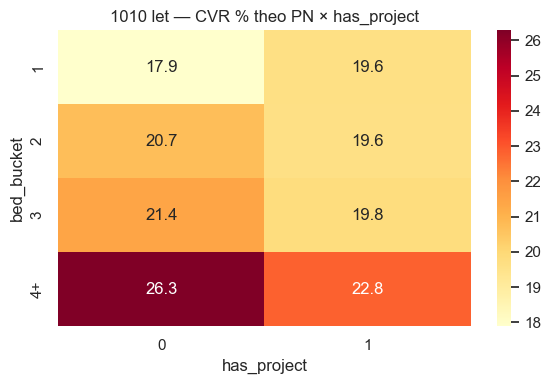

In [4]:
c1010 = cvr_by_dims(
    "l.ad_type, l.has_project, l.bed_bucket, l.has_furnishing",
    where="l.category = 1010",
)
assert_cvr_sane(c1010, "1010 slices")
show_cvr_table(c1010.head(40), "Bảng 3a — 1010: CVR theo ad_type × has_project × bed × furnishing (top 40 dòng)")
c1010.to_csv(OUT_DIR / "03a_cvr_1010_slices.csv", index=False)

# Heat: let only — bed_bucket × has_project
sub = c1010[(c1010.ad_type == "let")].groupby(["bed_bucket", "has_project"], as_index=False).agg(
    listings=("listings", "sum"),
    pos=("listings_with_positive", "sum"),
)
sub["cvr_pct"] = (100.0 * sub["pos"] / sub["listings"]).round(2)
piv = sub.pivot(index="bed_bucket", columns="has_project", values="cvr_pct")
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(piv, annot=True, fmt=".1f", cmap="YlOrRd", ax=ax)
ax.set_title("1010 let — CVR % theo PN × has_project")
plt.tight_layout()
fig.savefig(OUT_DIR / "fig_1010_let_cvr_bed_x_project.png", dpi=120, bbox_inches="tight")
plt.show()

## 4 — Đặc trưng **chỉ meaningful 1020** → CVR theo lát cắt

- `house_type`, `floors` bucket, `width_m` có/không, `legal_status` có/không  
- `project_id` thưa ở 1020 — chỉ xem nhanh, không làm feature chính.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

**Bảng 4 — 1020: CVR theo house_type × floors × width × legal (top 35 theo volume)**

,ad_type,house_type,floors_bucket,has_width_m,has_legal,listings,listings_with_positive,cvr_pct
0,sell,"Nhà ngõ, hẻm",1-2,1,1,205445,42189,20.54
1,sell,"Nhà ngõ, hẻm",unknown_or_0,1,1,151991,25937,17.06
2,sell,"Nhà ngõ, hẻm",3-4,1,1,147344,28960,19.65
3,sell,"Nhà ngõ, hẻm",unknown_or_0,0,1,109461,17057,15.58
4,let,"Nhà ngõ, hẻm",unknown_or_0,1,1,74148,11263,15.19
5,let,"Nhà ngõ, hẻm",1-2,1,1,67896,12902,19.00
6,sell,"Nhà mặt phố, mặt tiền",1-2,1,1,66324,13043,19.67
7,sell,"Nhà mặt phố, mặt tiền",unknown_or_0,1,1,64114,11001,17.16
8,sell,"Nhà mặt phố, mặt tiền",3-4,1,1,58926,11716,19.88
9,sell,"Nhà ngõ, hẻm",5+,1,1,54052,9017,16.68


/var/folders/gl/t2pfk0nn6r11bnblrgzwmq8m0000gn/T/ipykernel_9012/3389637445.py:58: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha="right")


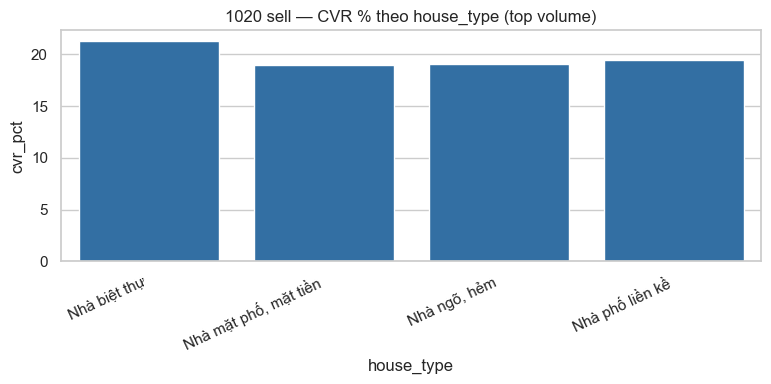

In [5]:
c1020_ht = cvr_by_dims(
    "l.ad_type, l.house_type, l.floors_bucket, l.has_width_m, l.has_legal",
    where="l.category = 1020",
)
c1020_ht = c1020_ht.sort_values("listings", ascending=False).reset_index(drop=True)
assert_cvr_sane(c1020_ht, "1020 slices")
show_cvr_table(c1020_ht.head(35), "Bảng 4 — 1020: CVR theo house_type × floors × width × legal (top 35 theo volume)")
c1020_ht.to_csv(OUT_DIR / "04_cvr_1020_slices.csv", index=False)

# Top house_type for sell
top_ht = (
    c1020_ht[c1020_ht.ad_type == "sell"]
    .groupby("house_type", as_index=False)["listings"]
    .sum()
    .sort_values("listings", ascending=False)
    .head(8)["house_type"]
)
sell_ht = c1020_ht[(c1020_ht.ad_type == "sell") & (c1020_ht.house_type.isin(top_ht))]
sell_ht = sell_ht.groupby("house_type", as_index=False).agg(
    listings=("listings", "sum"), pos=("listings_with_positive", "sum")
)
sell_ht["cvr_pct"] = (100.0 * sell_ht["pos"] / sell_ht["listings"]).round(2)
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=sell_ht, x="house_type", y="cvr_pct", ax=ax, color="#2171b5")
ax.set_title("1020 sell — CVR % theo house_type (top volume)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha="right")
plt.tight_layout()
fig.savefig(OUT_DIR / "fig_1020_sell_cvr_house_type.png", dpi=120, bbox_inches="tight")
plt.show()

## 5 — Chiều **dùng chung** (primary cả hai): `area_sqm` bucket × `ad_type`

So sánh **cùng định nghĩa bucket** giữa 1010 và 1020 — vẫn cần đọc cùng với mix `let/sell` khác nhau (mục 1).

In [ ]:
area_cvr = attach_labels(
    cvr_by_dims("l.category, l.ad_type, l.area_bucket")
)
area_cvr["area_bucket"] = pd.Categorical(
    area_cvr["area_bucket"], categories=list(AREA_BUCKET_ORDER), ordered=True
)
area_cvr = area_cvr.sort_values(["category", "ad_type", "area_bucket"]).reset_index(drop=True)
assert_cvr_sane(area_cvr, "area_bucket")
show_cvr_table(area_cvr, "Bảng 5 — CVR theo area_bucket × ad_type (catalog)")
area_cvr.to_csv(OUT_DIR / "05_cvr_area_bucket_shared.csv", index=False)

order = ["<30", "30-50", "50-80", "80-120", "120+", "unknown_or_0"]
ymax = max(5.0, float(area_cvr["cvr_pct"].max()) * 1.15)
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, adt in zip(axes, ["let", "sell"]):
    sub = area_cvr[area_cvr.ad_type == adt].copy()
    sub["area_bucket"] = pd.Categorical(sub["area_bucket"], categories=order, ordered=True)
    sub = sub.sort_values(["category", "area_bucket"])
    for cat, sty in [(1010, "#238b45"), (1020, "#2171b5")]:
        s = sub[sub.category == cat]
        ax.plot(s["area_bucket"].astype(str), s["cvr_pct"], marker="o", label=UI_LABELS[cat], color=sty)
    ax.set_title(f"ad_type = {adt}")
    ax.set_xlabel("area_bucket (sqm)")
    ax.set_ylabel("CVR %")
    ax.set_ylim(0, ymax)
    ax.legend()
    ax.tick_params(axis="x", rotation=30)
plt.suptitle("CVR theo diện tích — 1010 vs 1020 (catalog 1010+1020)")
plt.tight_layout()
fig.savefig(OUT_DIR / "fig_cvr_area_curves_1010_1020.png", dpi=120, bbox_inches="tight")
plt.show()

## 6 — Tóm tắt đọc nhanh

- **Đối chiếu đặc trưng:** dùng bảng 1 để thấy vì sao pattern CVR khác (vd. 1010 nhiều `let` + `project_id`; 1020 nhiều `sell` + `house_type`/`floors`).
- **Không** kết luận “1010 tốt hơn 1020” chỉ từ CVR thô — mix giao dịch và form field khác nhau.
- Nếu RAM thấp: đặt `EVENT_SAMPLE_FRAC = 0.08` ở cell setup rồi **Run All** (không dùng `0`).
- Nếu chart CVR = 0: lỗi SQL `ROUND(..., 2,)` hoặc chạy lẻ cell — **Run All** từ setup.
- §0: `posted_cohort` giải thích lệch `posted_date` vs facts; chart §2–§5 = catalog `dim_listing`.

---

## 7 — Tiếp theo: Behavioral clustering

Notebook **`eda_category_1010_1020_clustering.ipynb`**: user intent / listing / seller / session clustering (UMAP + HDBSCAN) + marketplace health segments → `outputs/eda_category_1010_1020/clustering/`.